# Lab 01 - Classifying Spam Emails

Notebook này đi theo flow phân tích rõ ràng từ dữ liệu thô đến mô hình tối ưu sử dụng các đặc trưng kết hợp văn bản và thông tin bổ trợ (Text + Metadata) trên các mô hình tự viết (scratch):

| Bước | Tên Bước | Nội dung | Thư mục/Mã nguồn liên quan |
| --- | --- | --- | --- |
| **Step 0** | Setup & Imports | Thiết lập đường dẫn thư mục dự án và nạp các thư viện, module bổ trợ. | `notebooks/utils.py`, `notebooks/model_from_scratch.py` |
| **STEP 1** | Read Data | Đọc tập dữ liệu Raw và tập dữ liệu nhẹ đã qua xử lý sơ bộ. Kiểm tra thông tin & thống kê mô tả. | `crawl.load_datasets` |
| **STEP 2** | Raw Data EDA | Phân tích và trực quan hóa phân phối nhãn (label) và nguồn dữ liệu (sources) trên tập Raw. | `eda.plot_label_distribution` |
| **STEP 3** | Check Quality (Raw) | Kiểm tra tỷ lệ khuyết thiếu (missing data) và số dòng trùng lặp (duplicates) trong tập Raw. | `preprocess.missing_data_summary` |
| **STEP 4** | Clean & Preprocess | Tiến hành làm sạch văn bản email, lọc dữ liệu huấn luyện, kiểm tra chất lượng sau tiền xử lý. | `preprocess.clean_email_text` |
| **STEP 5** | Split Data (3-Way) | Làm giàu dữ liệu bằng thông tin bổ trợ (subject, sender, source). Chia dữ liệu thành 3 tập Train (70%), Validation (15%), Test (15%) và vẽ biểu đồ EDA cho từng tập. | `model_checker.split_train_validation_test` |
| **STEP 6** | Balance Train Data | Cân bằng dữ liệu (downsampling) trên tập Train (tỷ lệ 1:1) để so sánh Balanced vs. Unbalanced, trực quan hóa phân phối. | `preprocess.balance_dataset` |
| **STEP 7** | Feature Engineering | Trích xuất đặc trưng TF-IDF từ văn bản đã bổ trợ metadata trên tập huấn luyện đã cân bằng. | `model_checker.tfidf_feature_preview` |
| **STEP 8** | Train Scratch Models | Huấn luyện 3 mô hình từ đầu (Multinomial NB, Logistic Regression, Linear SVM) sử dụng đặc trưng Text + Metadata trên tập Balanced và Unbalanced Train. | `model_from_scratch.py` |
| **STEP 9** | Sklearn Double Check | So sánh logic huấn luyện và dự đoán của 3 mô hình tự viết (scratch) vs. thư viện scikit-learn trên một cell duy nhất. | scikit-learn comparison |
| **STEP 10** | Threshold Tuning | Dò tìm ngưỡng tối ưu trên tập Validation (target FPR <= 1%), vẽ ROC/Confusion Matrix và phân tích lỗi trên Test. | `utils.run_threshold_tuning` |
| **STEP 11** | Save Model | Lưu trữ mô hình Scratch tối ưu (kèm vectorizer và ngưỡng), chạy thử nghiệm email mới và in báo cáo. | `joblib.dump` |


## Step 0 — Import Libraries And Setup


In [48]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

for module_path in [NOTEBOOKS_DIR, PROJECT_ROOT]:
    module_path = str(module_path)
    if module_path in sys.path:
        sys.path.remove(module_path)
    sys.path.insert(0, module_path)

import crawl
import preprocess
import model_from_scratch
import eda
import utils

crawl = importlib.reload(crawl)
preprocess = importlib.reload(preprocess)
model_from_scratch = importlib.reload(model_from_scratch)
eda = importlib.reload(eda)
utils = importlib.reload(utils)
model_checker = model_from_scratch.SklearnModelChecker()

paths = crawl.project_paths(PROJECT_ROOT)
print(f"crawl module: {crawl.__file__}")
print(f"preprocess module: {preprocess.__file__}")
print(f"model module: {model_from_scratch.__file__}")
print(f"eda module: {eda.__file__}")
print(f"utils module: {utils.__file__}")
PROJECT_ROOT

crawl module: /Users/quangmanh/Project/lab01/notebooks/crawl.py
preprocess module: /Users/quangmanh/Project/lab01/notebooks/preprocess.py
model module: /Users/quangmanh/Project/lab01/notebooks/model_from_scratch.py
eda module: /Users/quangmanh/Project/lab01/notebooks/eda.py
utils module: /Users/quangmanh/Project/lab01/notebooks/utils.py


PosixPath('/Users/quangmanh/Project/lab01')

## STEP 1 — Read Data: Raw + Light Processed Data

Load dữ liệu raw và file processed hiện có để đối chiếu. Hiển thị head, info, và describe của tập dữ liệu raw.


In [49]:
data, raw_data, paths = crawl.load_datasets(PROJECT_ROOT)
processed_data = data.copy().reset_index(drop=True)
overview = crawl.dataset_overview(processed_data, raw_data)

print(f"Processed rows: {overview['processed_rows']:,}")
print(f"Raw rows: {overview['raw_rows']:,}" if overview["raw_rows"] else "Raw dataset not found")

print("\n--- Raw data head ---")
display(raw_data.head(3))

print("\n--- Raw data info ---")
raw_data.info()

print("\n--- Raw data statistics ---")
display(raw_data.describe(include='all'))


Processed rows: 9,886
Raw rows: 18,807

--- Raw data head ---


,email_id,source,source_family,source_url,local_path,extracted_from,extracted_path,archive_path,label,sender,recipient,subject,body,text
0,ce51395fd8e8257c13facf3140cfb9496fedc8cada23f1...,spamassassin_20021010_easy_ham,spamassassin,https://spamassassin.apache.org/old/publiccorp...,/Users/quangmanh/Project/lab01/data/raw/downlo...,/Users/quangmanh/Project/lab01/data/raw/downlo...,easy_ham/1011.82f644586fced13704dd79e22c3d8fb9,easy_ham/1011.82f644586fced13704dd79e22c3d8fb9,ham,John Hall <johnhall@evergo.net>,fork@example.com,RE: The Curse of India's Socialism,> From: fork-admin@xent.com [mailto:fork-admin...,RE: The Curse of India's Socialism > From: for...
1,fb481d334002f416cff290374cff170831ea647f93dc8a...,spamassassin_20021010_easy_ham,spamassassin,https://spamassassin.apache.org/old/publiccorp...,/Users/quangmanh/Project/lab01/data/raw/downlo...,/Users/quangmanh/Project/lab01/data/raw/downlo...,easy_ham/1051.cf81a19208b703f18497a0d6fedb1f13,easy_ham/1051.cf81a19208b703f18497a0d6fedb1f13,ham,Ingo Frommholz <ingo@frommholz.org>,exmh-users@example.com,"Re: ARRRGHHH Had GPG working, now it doesnt.","Hi,\n\nOn Sun, 01 Sep 2002 00:05:03 MDT Reg Cl...","Re: ARRRGHHH Had GPG working, now it doesnt. H..."
2,95d692d420799d95e442a19b697ad72ad3d8716aeac3d9...,spamassassin_20021010_easy_ham,spamassassin,https://spamassassin.apache.org/old/publiccorp...,/Users/quangmanh/Project/lab01/data/raw/downlo...,/Users/quangmanh/Project/lab01/data/raw/downlo...,easy_ham/1091.0bade8676340d304cae87dad02efa8ce,easy_ham/1091.0bade8676340d304cae87dad02efa8ce,ham,Tony Nugent <tony@linuxworks.com.au>,exmh-users@example.com,Re: bad focus/click behaviours,"On Fri Sep 13 2002 at 02:03, Robert Elz wrote:...",Re: bad focus/click behaviours On Fri Sep 13 2...



--- Raw data info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18807 entries, 0 to 18806
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   email_id        18807 non-null  object
 1   source          18807 non-null  object
 2   source_family   18807 non-null  object
 3   source_url      18807 non-null  object
 4   local_path      18807 non-null  object
 5   extracted_from  18807 non-null  object
 6   extracted_path  18807 non-null  object
 7   archive_path    18807 non-null  object
 8   label           18807 non-null  object
 9   sender          18807 non-null  object
 10  recipient       18807 non-null  object
 11  subject         18807 non-null  object
 12  body            18807 non-null  object
 13  text            18807 non-null  object
dtypes: object(14)
memory usage: 2.0+ MB

--- Raw data statistics ---


,email_id,source,source_family,source_url,local_path,extracted_from,extracted_path,archive_path,label,sender,recipient,subject,body,text
count,18807,18807,18807,18807,18807,18807,18807,18807,18807,18807,18807,18807,18807,18807
unique,18807,18,11,18,18,17,17830,17830,2,1831,1230,8647,18135,18807
top,ce51395fd8e8257c13facf3140cfb9496fedc8cada23f1...,kaggle_enron_email_dataset,spamassassin,/Users/quangmanh/.cache/kagglehub/datasets/wcu...,/Users/quangmanh/.cache/kagglehub/datasets/wcu...,/Users/quangmanh/.cache/kagglehub/datasets/wcu...,train/16,train/16,ham,,,,,RE: The Curse of India's Socialism > From: for...
freq,1,5000,5187,5000,5000,5000,2,2,13616,13625,13813,8048,556,1


## STEP 2 — EDA with raw

Phân tích phân phối nhãn và nguồn dữ liệu của tập dữ liệu raw.


In [50]:
raw_eda_frame = raw_data if not raw_data.empty else data
display(crawl.label_counts(raw_eda_frame))
display(crawl.source_counts(raw_eda_frame, top_n=15))

,label,rows
0,ham,13616
1,spam,5191


,source_family,rows
0,spamassassin,5187
1,kaggle_enron_email_dataset,5000
2,kaggle_email_spam_classification,1000
3,aueb_enron3_spam_ham,999
4,huggingface_enron_spam,996
5,aueb_enron2_spam_ham,995
6,aueb_enron1_spam_ham,992
7,huggingface_kimdongh_spam_dataset,981
8,aueb_enron4_spam_ham,963
9,aueb_enron6_spam_ham,925


## STEP 3 — Check Missing and Duplicates in Raw Data

Kiểm tra chất lượng dữ liệu: tìm giá trị thiếu (missing value) và các dòng bị trùng lặp (duplicates) trong raw dataset.


,column,missing_count,missing_percent,dtype
0,archive_path,0,0.0,object
1,body,0,0.0,object
2,email_id,0,0.0,object
3,extracted_from,0,0.0,object
4,extracted_path,0,0.0,object
5,label,0,0.0,object
6,local_path,0,0.0,object
7,recipient,0,0.0,object
8,sender,0,0.0,object
9,source,0,0.0,object


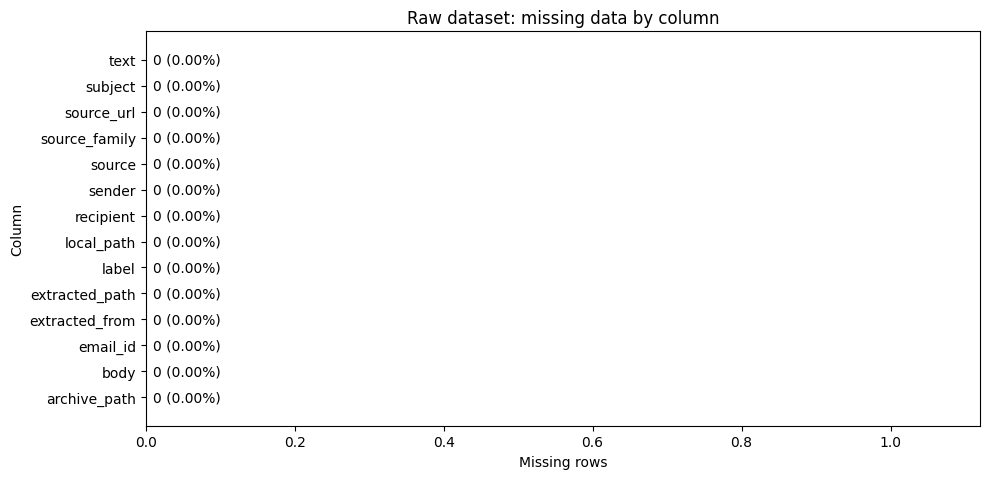

,subset,total_rows,unique_rows,duplicate_rows,duplicate_percent
0,all columns,18807,18807,0,0.0


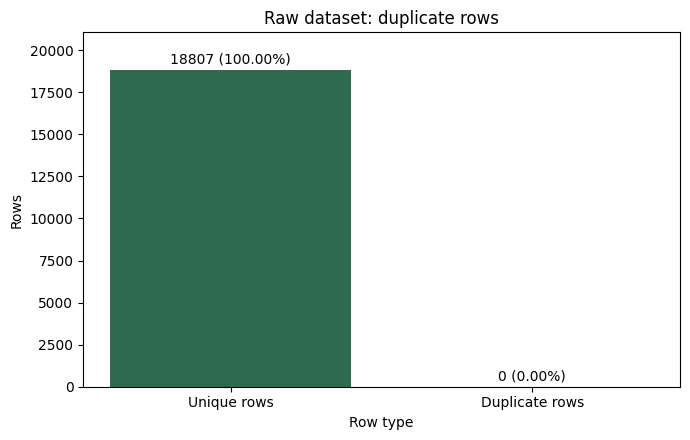

In [51]:
missing_summary = preprocess.missing_data_summary(raw_data)
display(missing_summary)
preprocess.plot_missing_data(raw_data, title="Raw dataset: missing data by column")

duplicate_summary = preprocess.duplicate_data_summary(raw_data)
display(duplicate_summary)
preprocess.plot_duplicate_data(raw_data, title="Raw dataset: duplicate rows")


## STEP 4 — Process raw. Clean and preprocess email text.

Sử dụng code trong `notebooks/preprocess.py` để làm sạch dữ liệu.


In [52]:
display(preprocess.processed_sample(data, rows=3, random_state=42))

raw_example, clean_example = preprocess.example_cleaning()
print("Raw example:")
print(raw_example)
print("\nCleaned example using notebooks/preprocess.py:")
print(clean_example)


,label,source_family,subject,body,clean_text
4170,spam,aueb_enron2_spam_ham,undeliverable : home based business for grownups,your message\r\nsubject : home based business ...,undeliverable home based business grownups mes...
5809,ham,spamassassin,Re: [ILUG] SUSE 8 disks? (thread changed sligh...,wintermute <cout@eircom.net> a écrit:\n\n\n> >...,ilug suse disks thread changed slightly winter...
3023,ham,kaggle_enron_email_dataset,,Message-ID: <15581064.1075855710484.JavaMail.e...,message-id javamail evans thyme tue mar pst mi...


Raw example:
<html><body><h1>WIN MONEY NOW!!!</h1>
Click https://example.com/prize and email winner@example.com to claim $5,000 today.
</body></html>

Cleaned example using notebooks/preprocess.py:
win money claim today


### STEP 4.1 — Raw-To-Clean Check On Real Rows

Cell này chứng minh preprocessing chạy trên dữ liệu raw thật, không chỉ trên ví dụ tự tạo.


In [53]:
raw_to_clean = preprocess.raw_to_clean_sample(raw_data, rows=5)
if raw_to_clean.empty:
    print("Raw dataset is not available, so this check is skipped.")
else:
    display(raw_to_clean)

,label,source_family,text,clean_text,raw_char_count,clean_char_count,clean_word_count
0,ham,spamassassin,RE: The Curse of India's Socialism > From: for...,curse india's socialism behalf james rogers cu...,1601,846,114
1,ham,spamassassin,"Re: ARRRGHHH Had GPG working, now it doesnt. H...",arrrghhh gpg working doesnt hi sun sep mdt reg...,987,460,69
2,ham,spamassassin,Re: bad focus/click behaviours On Fri Sep 13 2...,bad focus behaviours fri sep robert elz wrote ...,1527,674,102
3,ham,spamassassin,"Re: ALSA (almost) made easy On Thu, 2002-08-29...",alsa easy thu matthias saou wrote thanks lot r...,1442,699,108
4,ham,spamassassin,creating rpms with subdirs (install command) H...,creating rpms subdirs install command hi i'm b...,803,365,53


### STEP 4.2 — Quality check on data after preprocess

Kiểm tra lại missing và duplicate sau khi tiền xử lý dữ liệu.


In [54]:
full_clean_data, before_balance_data, unbalanced_processed_data = utils.run_preprocess_step(raw_data)

Full cleaned rows: 18,323
Trainable rows after preprocess, before balance: 12,960
Unbalanced label counts


,label,rows
0,ham,8291
1,spam,4669


After preprocess, before balance: missing data in model/features columns


,column,missing_count,missing_percent,dtype
0,clean_char_count,0,0.0,int64
1,clean_text,0,0.0,object
2,clean_word_count,0,0.0,int64
3,label,0,0.0,object
4,raw_char_count,0,0.0,int64
5,source_family,0,0.0,object
6,subject,0,0.0,object
7,text,0,0.0,object


After preprocess, before balance: duplicate clean_text + label


,subset,total_rows,unique_rows,duplicate_rows,duplicate_percent
0,"clean_text, label",12960,12960,0,0.0


label,source_family,ham,spam,total,spam_rate
9,spamassassin,4091,668,4759,0.1404
2,aueb_enron3_spam_ham,493,494,987,0.5005
8,kaggle_email_spam_classification,437,547,984,0.5559
1,aueb_enron2_spam_ham,490,488,978,0.4990
0,aueb_enron1_spam_ham,491,456,947,0.4815
3,aueb_enron4_spam_ham,492,444,936,0.4744
7,huggingface_kimdongh_spam_dataset,471,446,917,0.4864
5,aueb_enron6_spam_ham,480,423,903,0.4684
6,huggingface_enron_spam,384,404,788,0.5127
4,aueb_enron5_spam_ham,462,299,761,0.3929


,analysis_char_count,analysis_word_count,subject_chars
count,12960.000000,12960.000000,12960.000000
mean,924.435802,124.972685,28.440895
std,2435.276217,286.998275,24.190895
min,25.000000,5.000000,0.000000
25%,239.750000,34.000000,10.000000
50%,474.500000,68.000000,27.000000
75%,942.000000,132.000000,42.000000
95%,2824.100000,379.050000,68.000000
max,120772.000000,15414.000000,452.000000


## STEP 5 — Split Data (3-Way) with Metadata Enrichment

Bổ sung đặc trưng kết hợp Text + Metadata (subject, sender, source) sử dụng hàm `utils.add_threshold_metadata_text`. Sau đó chia tập dữ liệu thành 3 tập Train (70%), Validation (15%), Test (15%) và hiển thị biểu đồ EDA phân tích nhãn/nguồn.


Train data size: 6,920 (70.0%)
Validation data size: 1,483 (15.0%)
Test data size: 1,483 (15.0%)

--- Train set label counts ---


,label,rows
0,ham,3803
1,spam,3117



--- Val set label counts ---


,label,rows
0,ham,815
1,spam,668



--- Test set label counts ---


,label,rows
0,ham,815
1,spam,668



--- Plotting EDA overview for Train data (with Metadata) ---


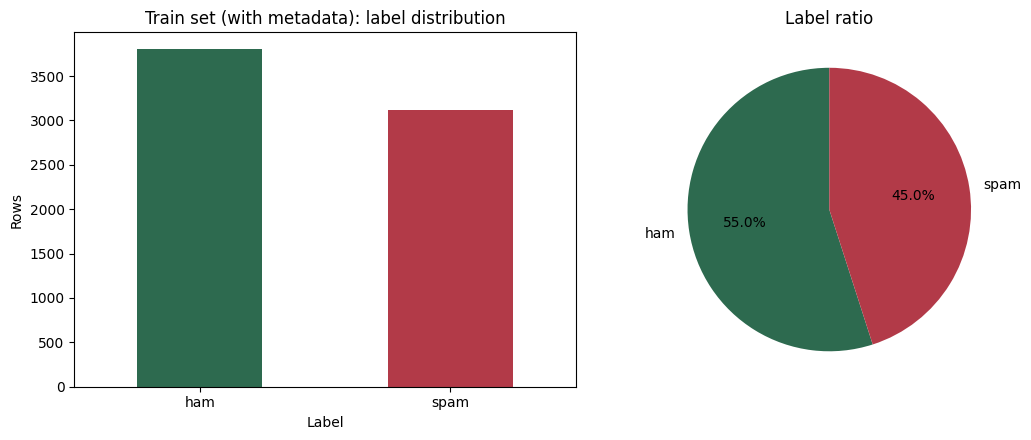

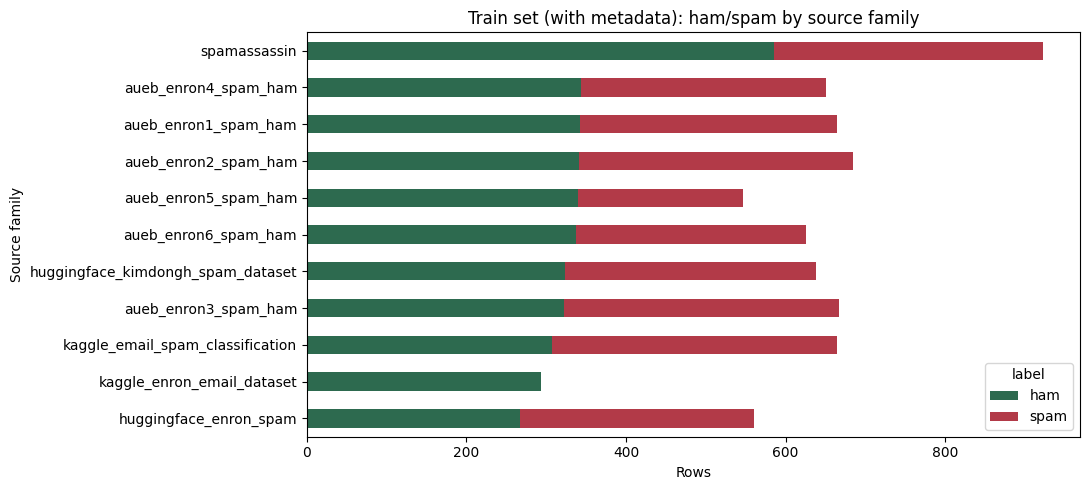

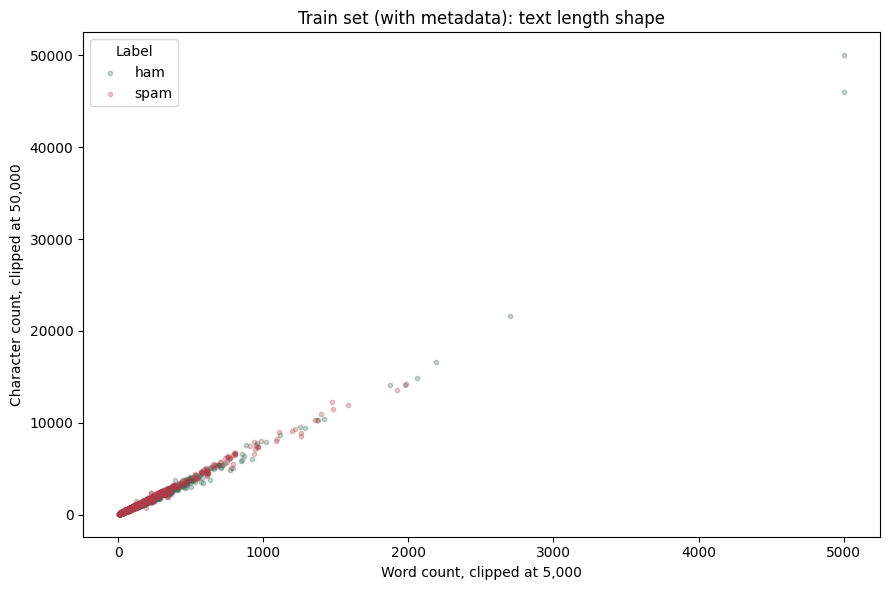

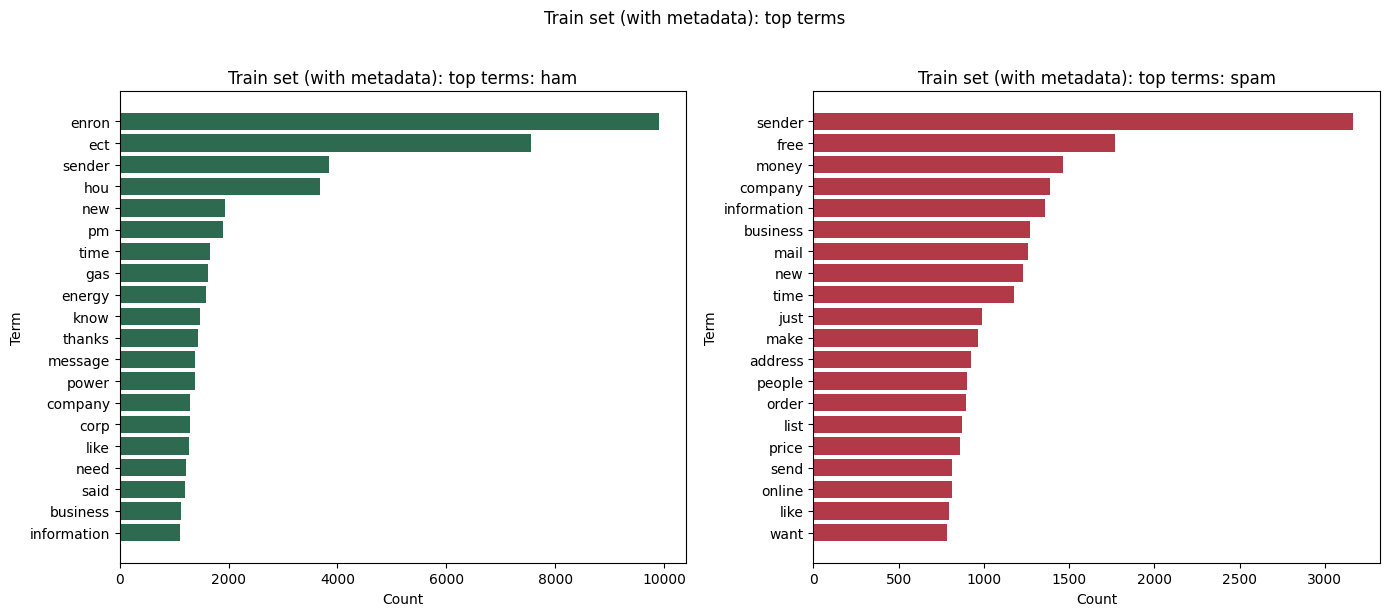

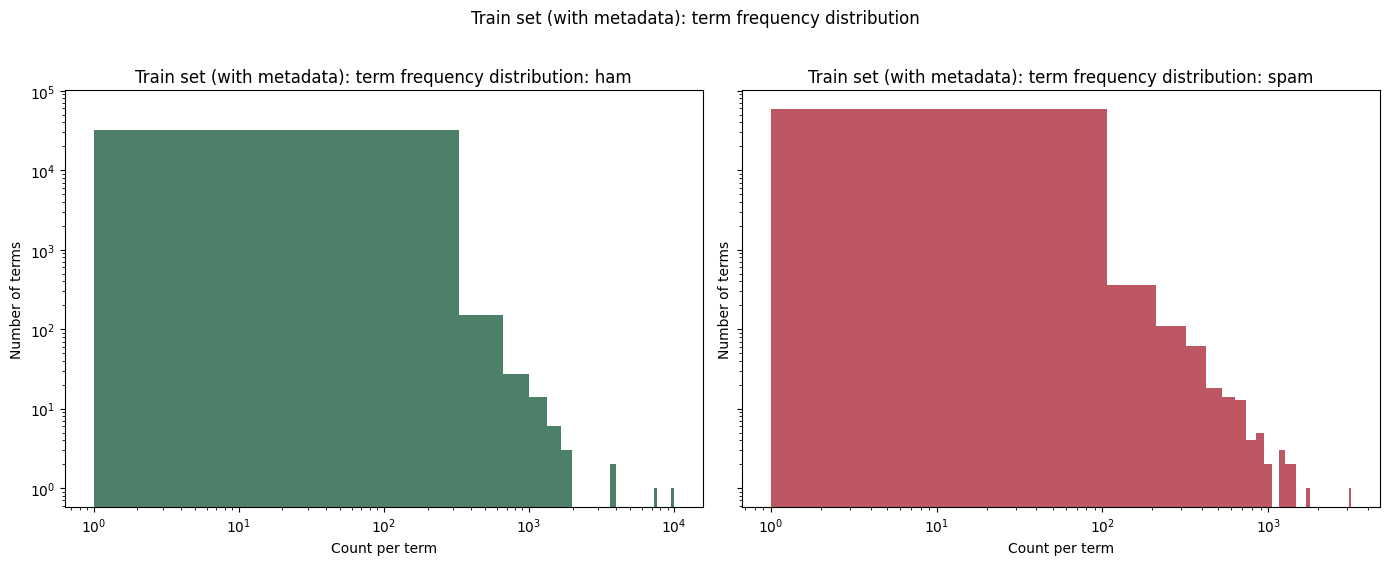


--- Plotting EDA overview for Validation data (with Metadata) ---


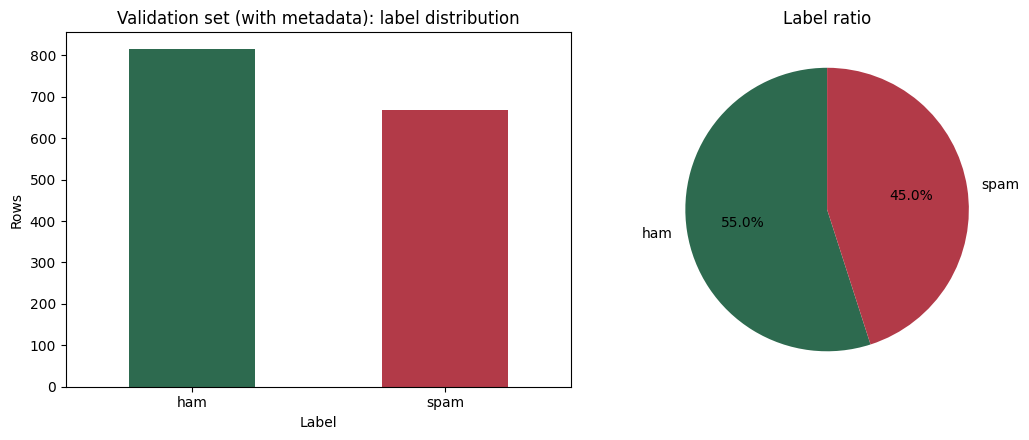

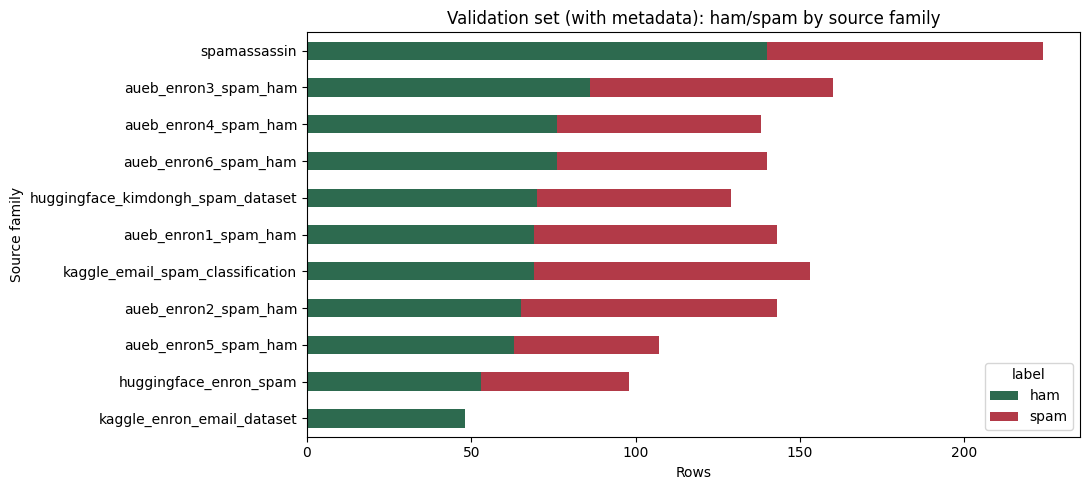

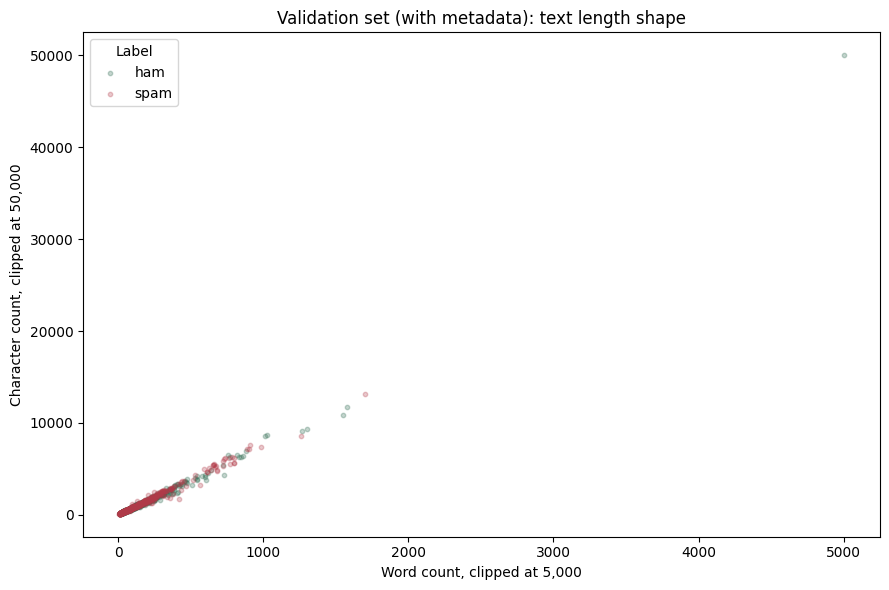

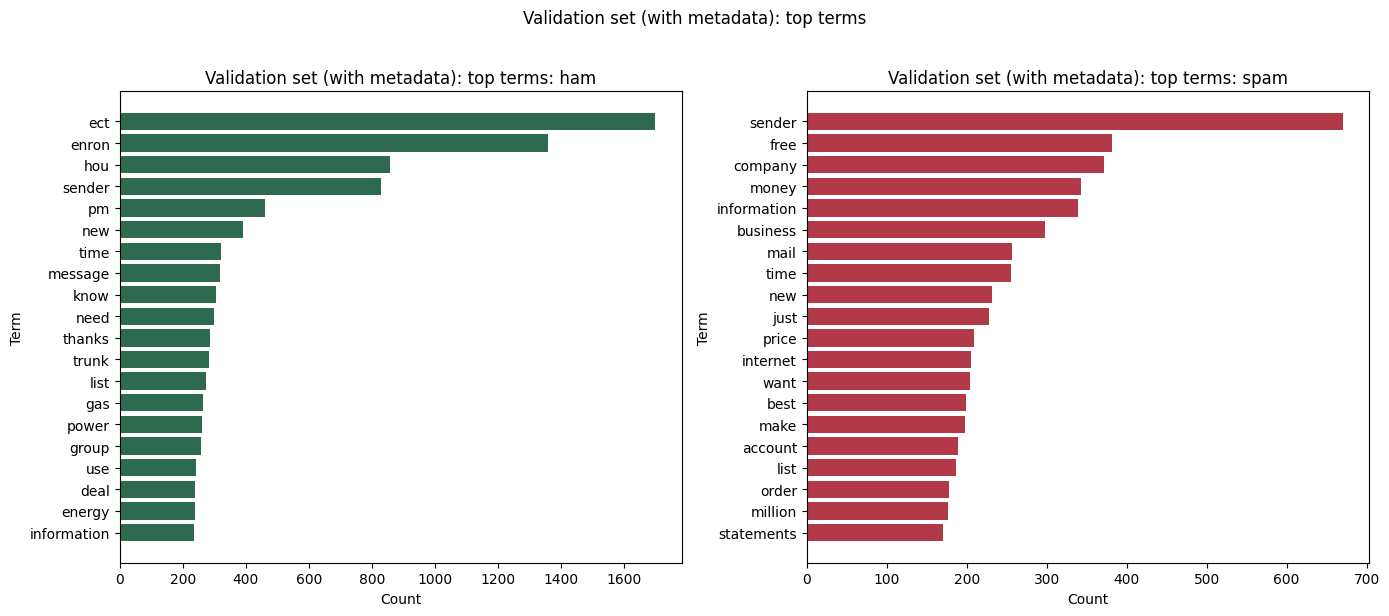

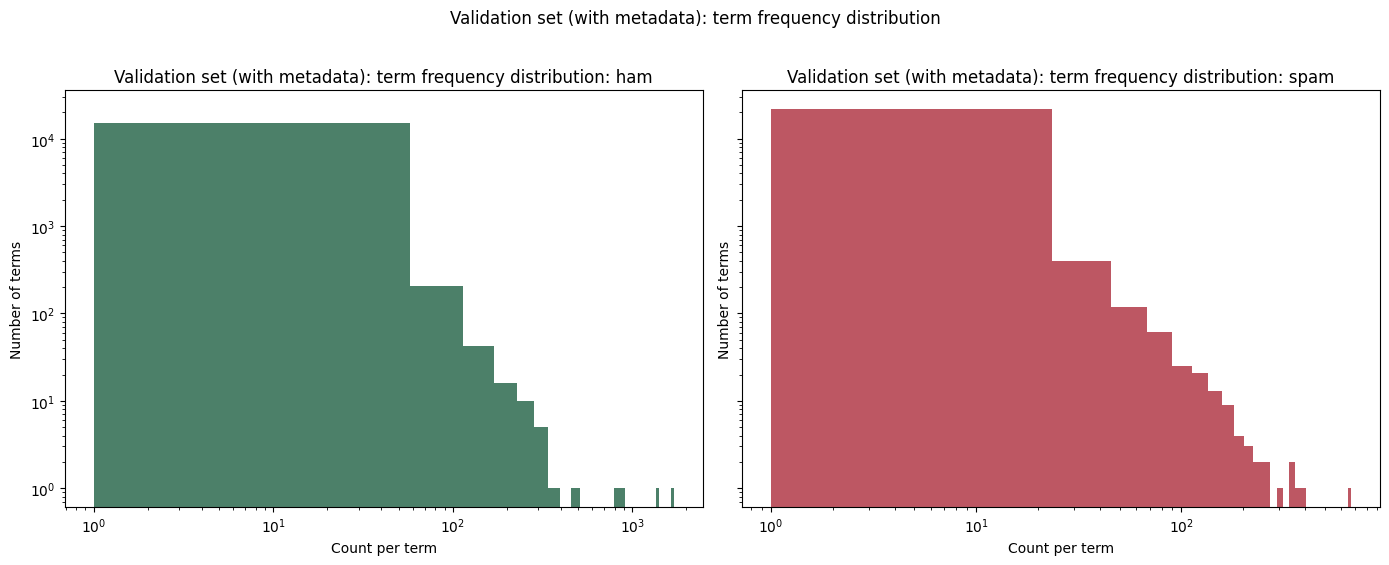


--- Plotting EDA overview for Test data (with Metadata) ---


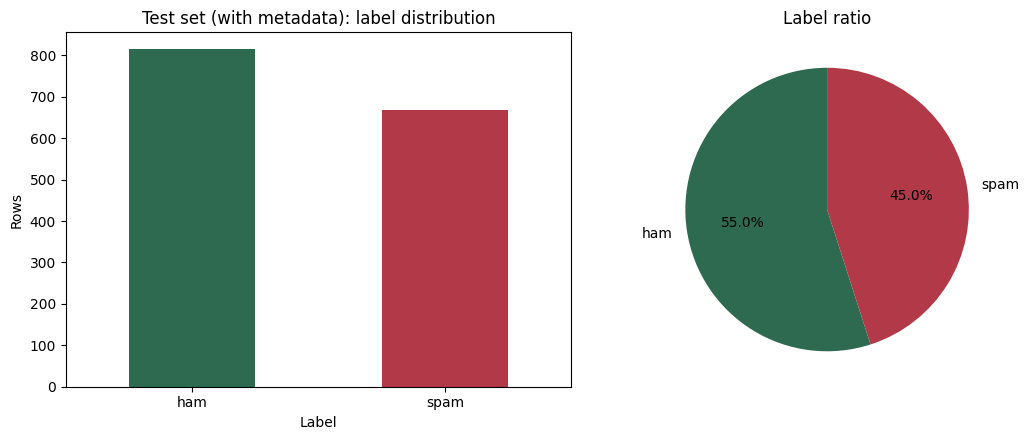

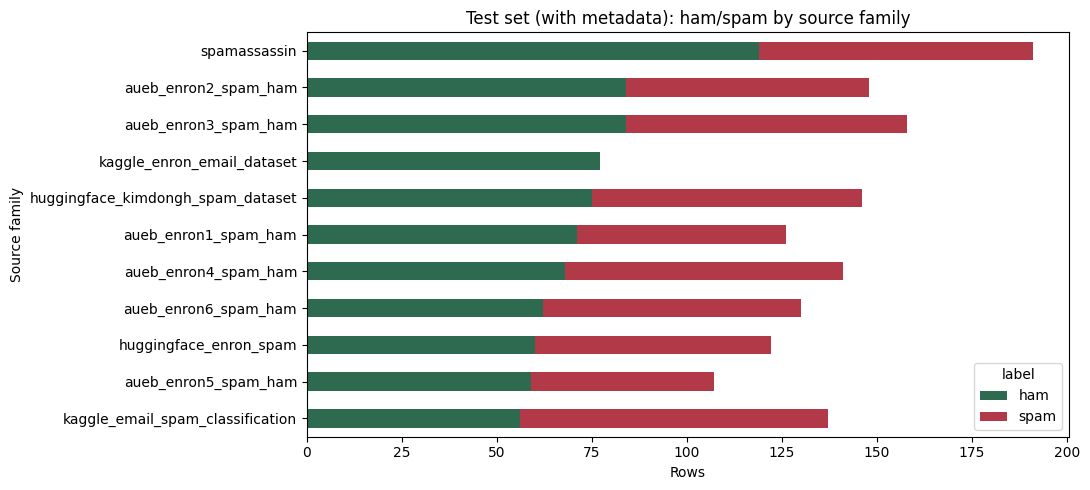

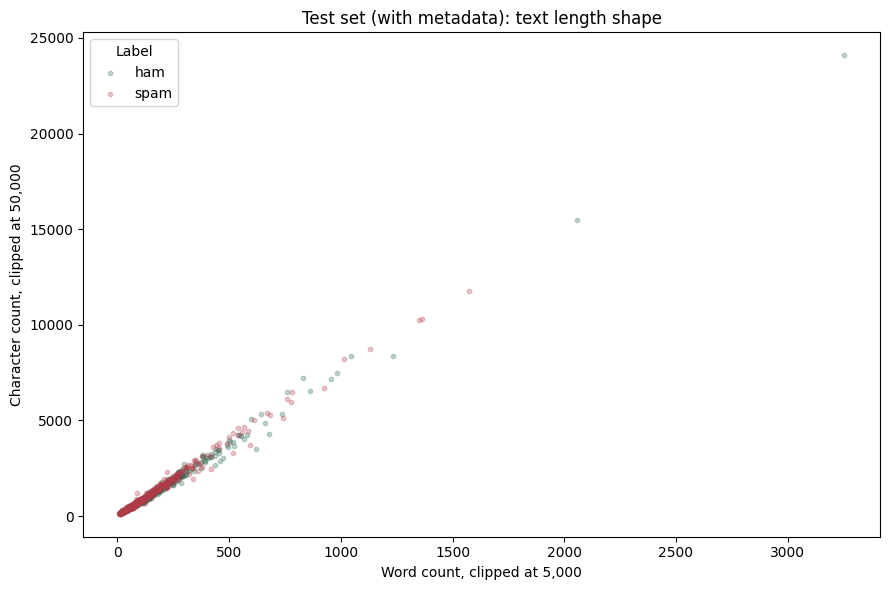

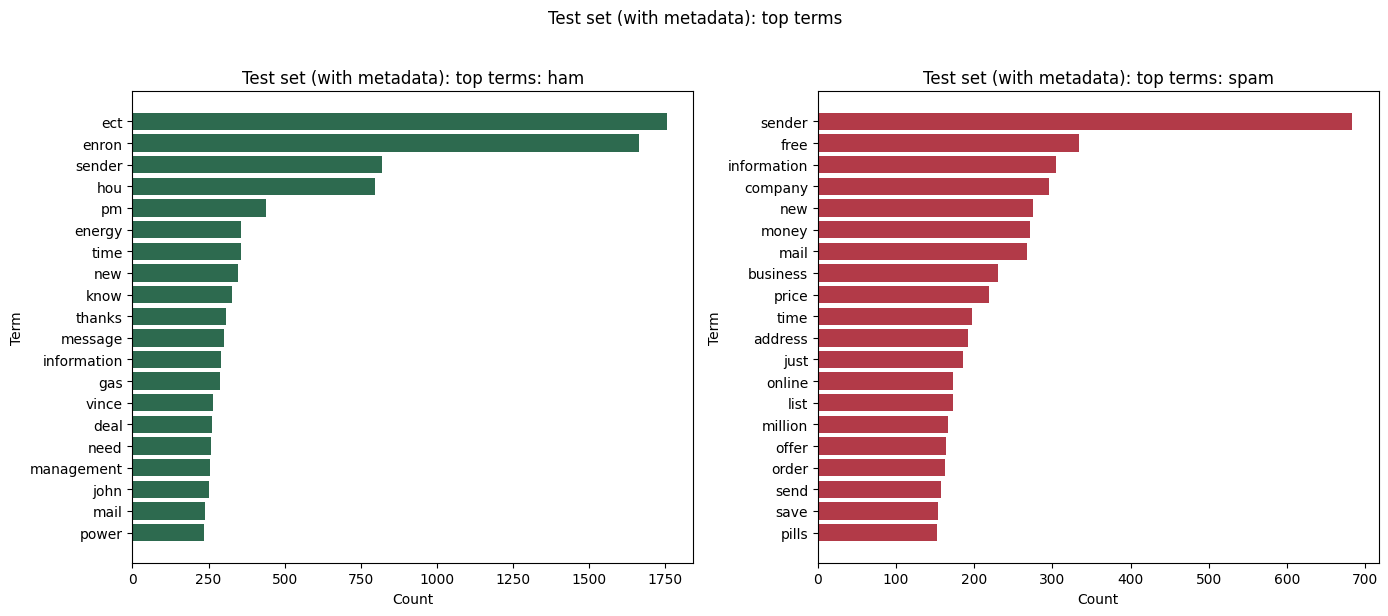

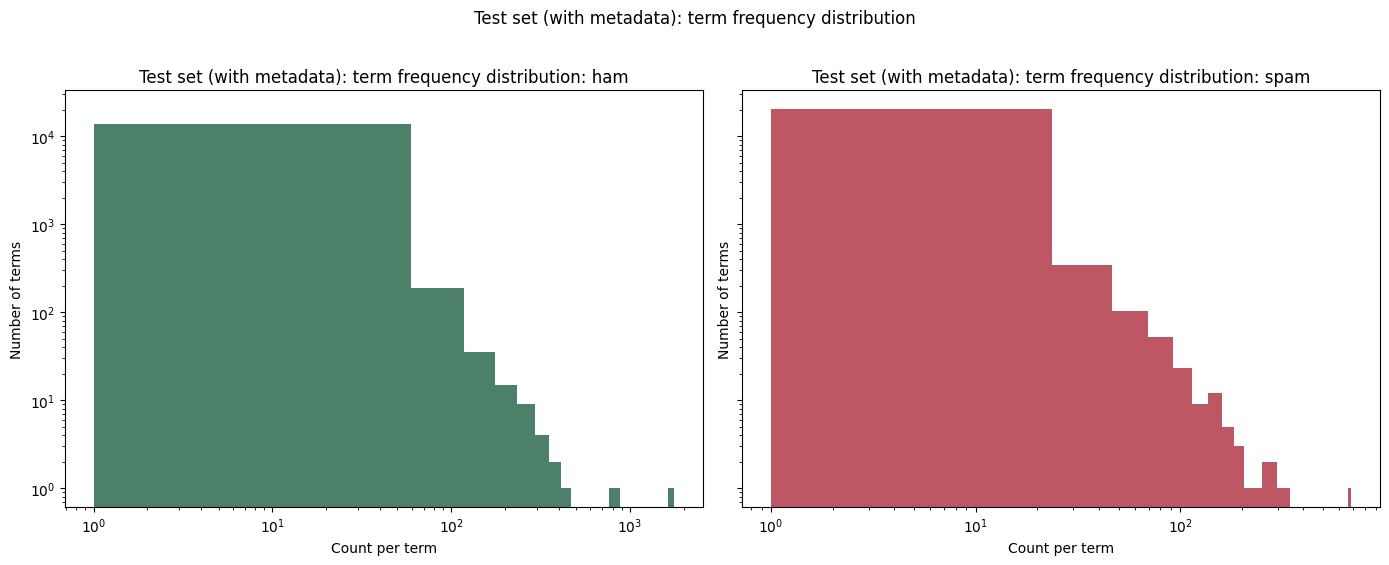

In [55]:
# Bổ sung thông tin metadata vào text
processed_data = utils.add_threshold_metadata_text(processed_data, "clean_text")

# Chia 3 tập Train, Val, Test phân tầng (stratified)
train_data, val_data, test_data = model_checker.split_train_validation_test(
    processed_data,
    validation_size=0.15,
    test_size=0.15,
    random_state=42
)

print(f"Train data size: {len(train_data):,} ({len(train_data)/len(processed_data)*100:.1f}%)")
print(f"Validation data size: {len(val_data):,} ({len(val_data)/len(processed_data)*100:.1f}%)")
print(f"Test data size: {len(test_data):,} ({len(test_data)/len(processed_data)*100:.1f}%)")

print("\n--- Train set label counts ---")
display(crawl.label_counts(train_data))
print("\n--- Val set label counts ---")
display(crawl.label_counts(val_data))
print("\n--- Test set label counts ---")
display(crawl.label_counts(test_data))

# Trực quan hóa EDA bằng cách phân tích đặc trưng văn bản đã làm giàu
print("\n--- Plotting EDA overview for Train data (with Metadata) ---")
train_eda_df = train_data.copy()
train_eda_df["clean_text"] = train_eda_df["clean_plus_meta"]
eda.plot_eda_overview(train_eda_df, title_prefix="Train set (with metadata)")

print("\n--- Plotting EDA overview for Validation data (with Metadata) ---")
val_eda_df = val_data.copy()
val_eda_df["clean_text"] = val_eda_df["clean_plus_meta"]
eda.plot_eda_overview(val_eda_df, title_prefix="Validation set (with metadata)")

print("\n--- Plotting EDA overview for Test data (with Metadata) ---")
test_eda_df = test_data.copy()
test_eda_df["clean_text"] = test_eda_df["clean_plus_meta"]
eda.plot_eda_overview(test_eda_df, title_prefix="Test set (with metadata)")


## STEP 6 — Balance Train Data & EDA

Cân bằng tập Train bằng phương pháp downsampling nhãn ham về bằng số lượng nhãn spam. Xem biểu đồ phân phối tập Balanced Train.


Unbalanced train rows: 6,920
Balanced train rows: 6,234

Unbalanced train label counts:


,label,rows
0,ham,3803
1,spam,3117



Balanced train label counts:


,label,rows
0,ham,3117
1,spam,3117



--- Plotting EDA overview for Balanced Train data (with Metadata) ---


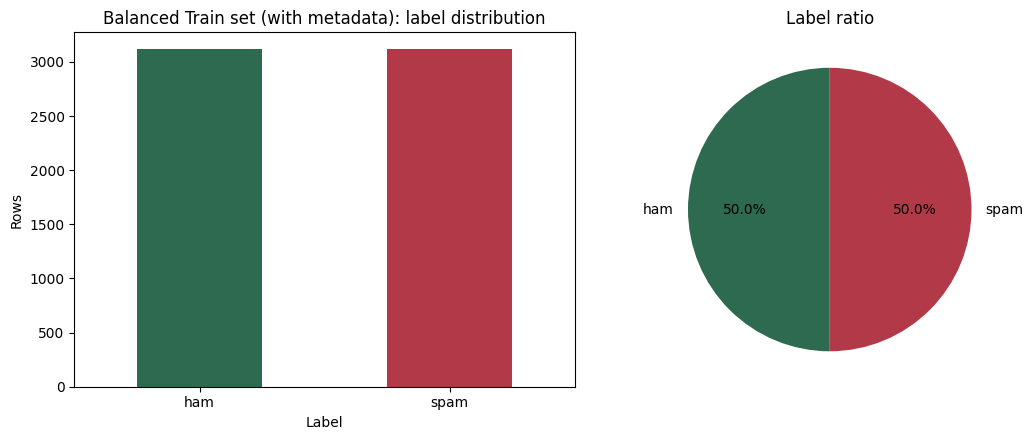

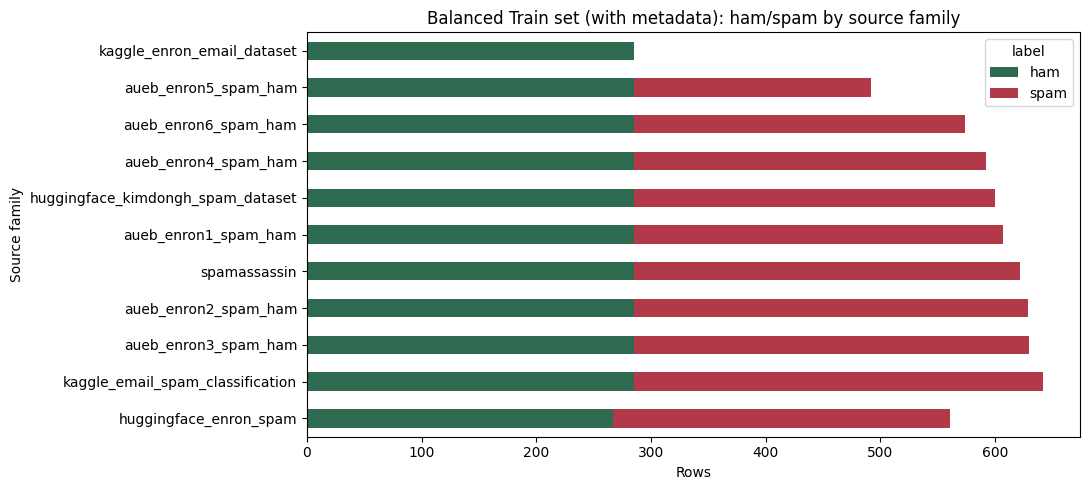

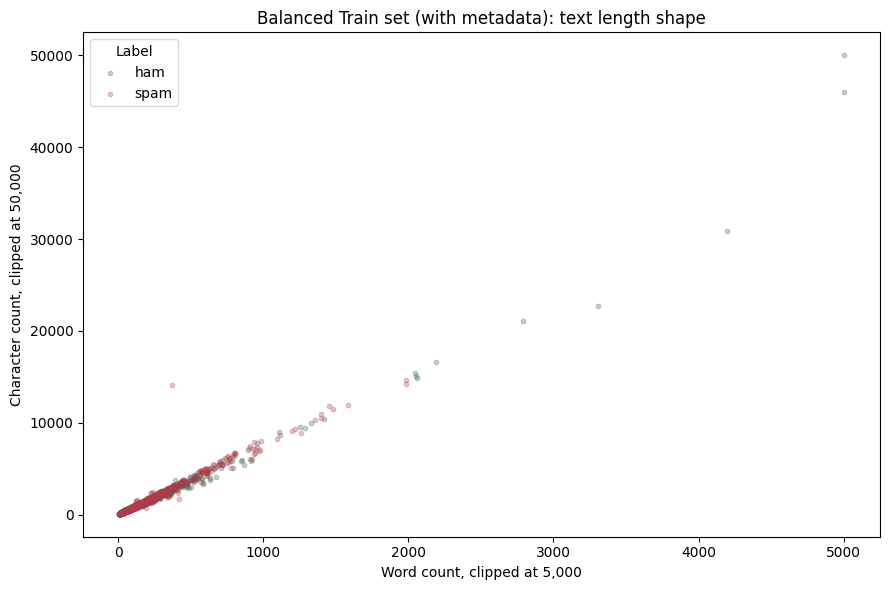

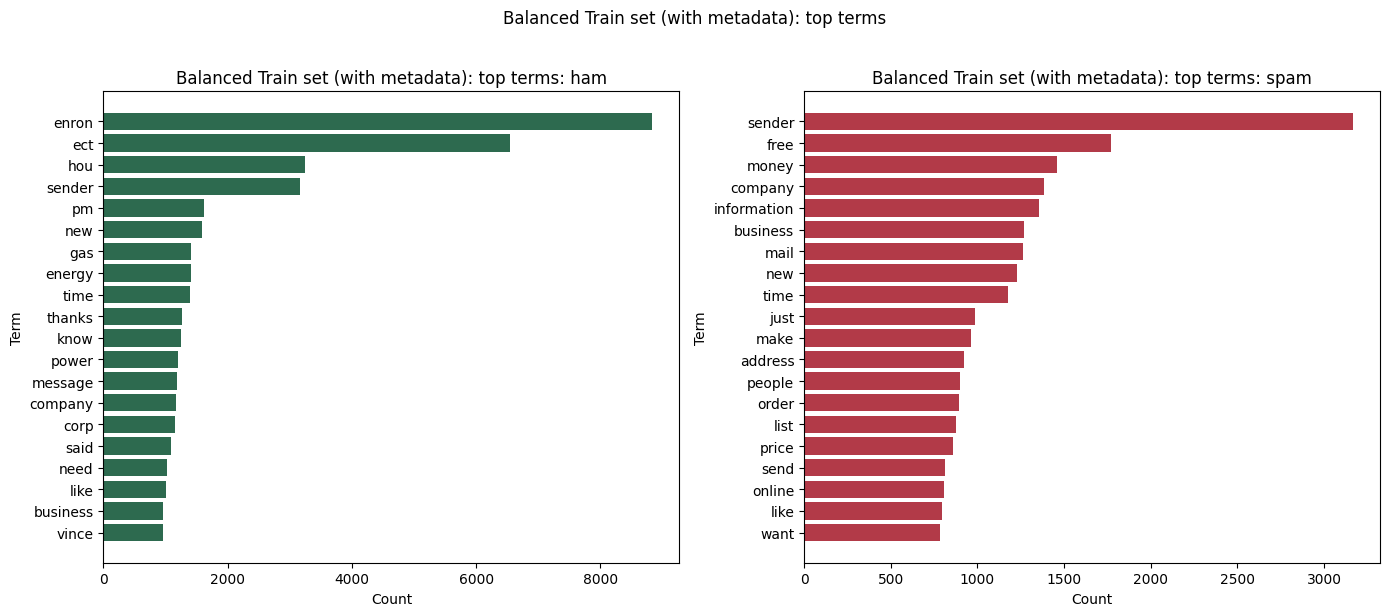

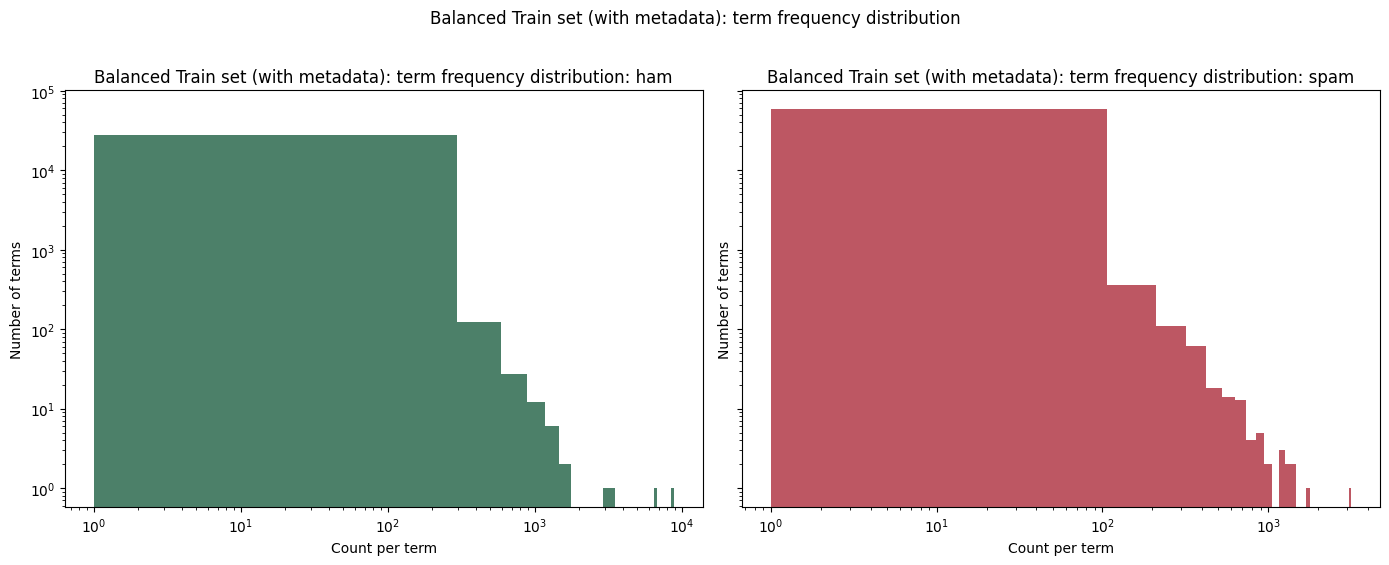

In [56]:
balanced_train_data = preprocess.balance_dataset(train_data, random_seed=42)

print(f"Unbalanced train rows: {len(train_data):,}")
print(f"Balanced train rows: {len(balanced_train_data):,}")

print("\nUnbalanced train label counts:")
display(crawl.label_counts(train_data))
print("\nBalanced train label counts:")
display(crawl.label_counts(balanced_train_data))

print("\n--- Plotting EDA overview for Balanced Train data (with Metadata) ---")
bal_eda_df = balanced_train_data.copy()
bal_eda_df["clean_text"] = bal_eda_df["clean_plus_meta"]
eda.plot_eda_overview(bal_eda_df, title_prefix="Balanced Train set (with metadata)")


## STEP 7 — Feature Engineering: TF-IDF

Trích xuất và hiển thị đặc trưng TF-IDF trên trường dữ liệu Text + Metadata (`clean_plus_meta`) của tập Balanced Train.


In [57]:
vectorizer = model_checker.make_tfidf_vectorizer()
tfidf_train_matrix = vectorizer.fit_transform(balanced_train_data["clean_plus_meta"])
tfidf_shape = tfidf_train_matrix.shape
tfidf_features = vectorizer.get_feature_names_out()[:30]

print(f"TF-IDF matrix shape (Balanced Train + Metadata): {tfidf_shape[0]:,} emails x {tfidf_shape[1]:,} features")
print("Example features:")
print(tfidf_features)


TF-IDF matrix shape (Balanced Train + Metadata): 6,234 emails x 121,220 features
Example features:
['000' '02' '02 20010206' '03t04' '04pm' '04pm dermot' '06t18' '100k'
 '105th' '105th congress' '10th' '10th 11th' '11th' '11th larry'
 '11th meeting' '128mb' '13th' '13th closing' '14th' '16th' '16th january'
 '18pm' '18pm angles' '18th' '1980s' '1990s' '19th' '1gb' '1m' '1m just']


## STEP 8 — Train Scratch Models & Default Evaluation

Huấn luyện 3 mô hình tự code (Multinomial NB, Logistic Regression, Linear SVM) trên tập dữ liệu đã kết hợp Metadata, báo cáo kết quả mặc định trên tập Validation.


In [58]:
train_modes = {
    "Unbalanced": train_data,
    "Balanced": balanced_train_data
}

# Khởi tạo mô hình scratch
scratch_models = {
    "Naive Bayes": model_from_scratch.ScratchMultinomialNB(alpha=1.0),
    "Logistic Regression": model_from_scratch.ScratchLogisticRegression(),
    "Linear SVM": model_from_scratch.ScratchLinearSVM()
}

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

results = []

for mode_name, train_df in train_modes.items():
    # Sử dụng đặc trưng clean_plus_meta
    vec = model_checker.make_tfidf_vectorizer()
    x_tr_mat = vec.fit_transform(train_df["clean_plus_meta"])
    x_val_mat = vec.transform(val_data["clean_plus_meta"])
    y_tr = train_df["label"].to_numpy()
    y_val = val_data["label"].to_numpy()
    
    for algo_name, model_inst in scratch_models.items():
        # Huấn luyện mô hình
        model_inst.fit(x_tr_mat, y_tr)
        # Dự đoán
        y_pred = model_inst.predict(x_val_mat)
        
        # Thống kê kết quả
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred, labels=["ham", "spam"]).ravel()
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, pos_label="spam", zero_division=0)
        rec = recall_score(y_val, y_pred, pos_label="spam", zero_division=0)
        
        results.append({
            "training_mode": mode_name,
            "model": algo_name,
            "val_accuracy": acc,
            "val_precision": prec,
            "val_recall/TPR": rec,
            "TN": tn, "FP": fp, "FN": fn, "TP": tp
        })
        
df_results = pd.DataFrame(results)
display(df_results)


,training_mode,model,val_accuracy,val_precision,val_recall/TPR,TN,FP,FN,TP
0,Unbalanced,Naive Bayes,0.973702,0.998415,0.943114,814,1,38,630
1,Unbalanced,Logistic Regression,0.597438,1.000000,0.106287,815,0,597,71
2,Unbalanced,Linear SVM,0.549562,0.000000,0.000000,815,0,668,0
3,Balanced,Naive Bayes,0.981794,0.979073,0.980539,801,14,13,655
4,Balanced,Logistic Regression,0.926500,0.861578,0.997006,708,107,2,666
5,Balanced,Linear SVM,0.964936,0.958333,0.964072,787,28,24,644


## STEP 9 — Sklearn Double Check

Kiểm chứng logic của 3 mô hình scratch vs. sklearn trên mẫu dữ liệu 3000 dòng huấn luyện (dùng clean_plus_meta). Đây là cell duy nhất gọi thư viện sklearn để so sánh.


Agreement with sklearn (Multinomial NB): 100.00%
Agreement with sklearn (Logistic Regression): 73.00%
Agreement with sklearn (Linear SVM): 55.80%


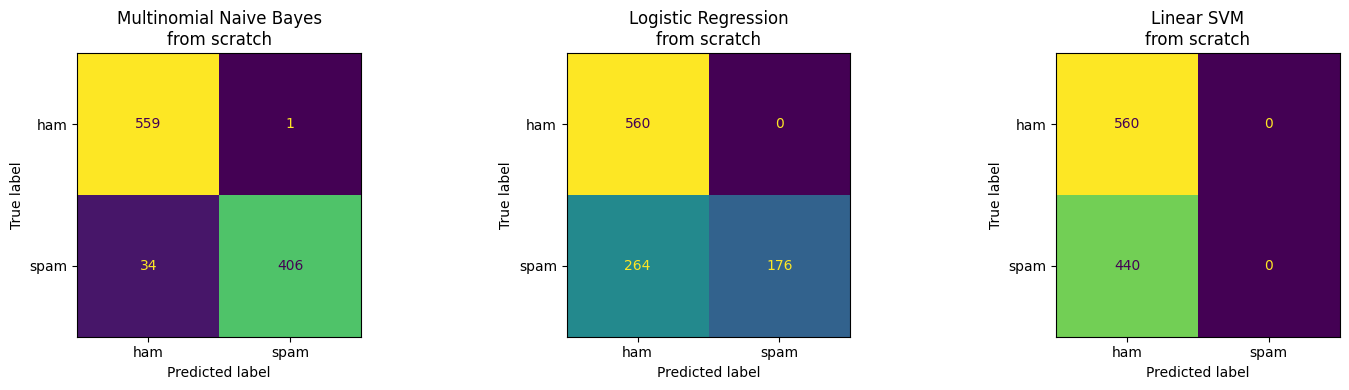

In [59]:
model_train_frame = train_data.sample(min(len(train_data), 3000), random_state=42)
model_test_frame = val_data.sample(min(len(val_data), 1000), random_state=42)

scratch_vectorizer = model_checker.make_tfidf_vectorizer()
x_train_matrix = scratch_vectorizer.fit_transform(model_train_frame["clean_plus_meta"])
x_test_matrix = scratch_vectorizer.transform(model_test_frame["clean_plus_meta"])
y_train_arr = model_train_frame["label"].to_numpy()
y_test_arr = model_test_frame["label"].to_numpy()

# Mô hình tự viết
scratch_nb_compare = model_from_scratch.ScratchMultinomialNB(alpha=1.0)
scratch_lr_compare = model_from_scratch.ScratchLogisticRegression()
scratch_svm_compare = model_from_scratch.ScratchLinearSVM()

scratch_nb_compare.fit(x_train_matrix, y_train_arr)
scratch_lr_compare.fit(x_train_matrix, y_train_arr)
scratch_svm_compare.fit(x_train_matrix, y_train_arr)

# Mô hình sklearn
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

sk_nb = MultinomialNB(alpha=1.0).fit(x_train_matrix, y_train_arr)
sk_lr = LogisticRegression(max_iter=1000).fit(x_train_matrix, y_train_arr)
sk_svm = LinearSVC(dual="auto").fit(x_train_matrix, y_train_arr)

# NB Agreement
nb_scratch_pred = scratch_nb_compare.predict(x_test_matrix)
nb_sk_pred = sk_nb.predict(x_test_matrix)
nb_agree = (nb_scratch_pred == nb_sk_pred).mean()

# LR Agreement
lr_scratch_pred = scratch_lr_compare.predict(x_test_matrix)
lr_sk_pred = sk_lr.predict(x_test_matrix)
lr_agree = (lr_scratch_pred == lr_sk_pred).mean()

# SVM Agreement
svm_scratch_pred = scratch_svm_compare.predict(x_test_matrix)
svm_sk_pred = sk_svm.predict(x_test_matrix)
svm_agree = (svm_scratch_pred == svm_sk_pred).mean()

print(f"Agreement with sklearn (Multinomial NB): {nb_agree*100:.2f}%")
print(f"Agreement with sklearn (Logistic Regression): {lr_agree*100:.2f}%")
print(f"Agreement with sklearn (Linear SVM): {svm_agree*100:.2f}%")

predictions_by_model = {
    "Multinomial Naive Bayes": nb_scratch_pred,
    "Logistic Regression": lr_scratch_pred,
    "Linear SVM": svm_scratch_pred
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, (model_name, scratch_predictions) in zip(axes, predictions_by_model.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_arr,
        scratch_predictions,
        labels=["ham", "spam"],
        ax=axis,
        colorbar=False,
    )
    axis.set_title(f"{model_name}\nfrom scratch")
plt.tight_layout()
plt.show()


## STEP 10 — Validation-Tuned Threshold For Balanced / Unbalanced & Test Metrics

Dò tìm ngưỡng tốt trên tập Validation với điều kiện ràng buộc FPR <= 1% sử dụng mô hình tự viết (scratch). Đánh giá hiệu năng trên tập Test (vẽ ROC và Confusion Matrix).


In [60]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

target_fpr = 0.01
positive_label = "spam"
negative_label = "ham"

train_modes = {
    "Unbalanced": train_data,
    "Balanced": balanced_train_data
}

results_tuning = []
val_roc_curves = []
test_matrices = []
trained_models = {}

for mode_name, train_df in train_modes.items():
    # Sử dụng trường clean_plus_meta
    vec = model_checker.make_tfidf_vectorizer()
    x_tr_mat = vec.fit_transform(train_df["clean_plus_meta"])
    x_val_mat = vec.transform(val_data["clean_plus_meta"])
    x_test_mat = vec.transform(test_data["clean_plus_meta"])
    
    y_tr = train_df["label"].to_numpy()
    y_val = val_data["label"].to_numpy()
    y_test_arr = test_data["label"].to_numpy()
    
    scratch_models = {
        "Naive Bayes": model_from_scratch.ScratchMultinomialNB(alpha=1.0),
        "Logistic Regression": model_from_scratch.ScratchLogisticRegression(),
        "Linear SVM": model_from_scratch.ScratchLinearSVM()
    }
    
    for algo_name, model_inst in scratch_models.items():
        model_inst.fit(x_tr_mat, y_tr)
        
        # Get scores
        if algo_name == "Linear SVM":
            val_scores = model_inst.decision_function(x_val_mat)
            test_scores = model_inst.decision_function(x_test_mat)
            score_type = "decision_score"
        else:
            spam_col = list(model_inst.classes_).index(positive_label)
            val_scores = model_inst.predict_proba(x_val_mat)[:, spam_col]
            test_scores = model_inst.predict_proba(x_test_mat)[:, spam_col]
            score_type = "probability"
            
        # ROC curve on validation to find threshold
        y_val_bin = (y_val == positive_label).astype(int)
        fpr, tpr, thresholds = roc_curve(y_val_bin, val_scores)
        
        # Find best threshold with FPR <= 1%
        survey = pd.DataFrame({"threshold": thresholds, "FPR": fpr, "TPR": tpr})
        under_fpr = survey[survey["FPR"] <= target_fpr]
        if under_fpr.empty:
            best_row = survey.sort_values(["FPR", "TPR"], ascending=[True, False]).iloc[0]
        else:
            best_row = under_fpr.sort_values(["TPR", "FPR"], ascending=[False, False]).iloc[0]
            
        best_thresh = best_row["threshold"]
        val_fpr = best_row["FPR"]
        val_tpr = best_row["TPR"]
        
        # Evaluate on Test set
        y_test_bin = (y_test_arr == positive_label).astype(int)
        test_preds = np.where(test_scores >= best_thresh, positive_label, negative_label)
        test_preds_bin = (test_preds == positive_label).astype(int)
        
        tn, fp, fn, tp = confusion_matrix(y_test_bin, test_preds_bin, labels=[0, 1]).ravel()
        test_acc = accuracy_score(y_test_bin, test_preds_bin)
        test_prec = precision_score(y_test_bin, test_preds_bin, zero_division=0)
        test_rec = recall_score(y_test_bin, test_preds_bin, zero_division=0)
        test_fpr = fp / (fp + tn) if (fp + tn) else 0
        
        results_tuning.append({
            "training_strategy": mode_name,
            "model": algo_name,
            "score_type": score_type,
            "selected_threshold": best_thresh,
            "validation_FPR": val_fpr,
            "validation_TPR": val_tpr,
            "validation_AUC": auc(fpr, tpr),
            "TN": tn, "FP": fp, "FN": fn, "TP": tp,
            "accuracy": test_acc,
            "precision": test_prec,
            "recall": test_rec,
            "test_FPR": test_fpr
        })
        
        val_roc_curves.append({
            "training_strategy": mode_name,
            "model": algo_name,
            "fpr": fpr,
            "tpr": tpr,
            "auc": auc(fpr, tpr),
            "selected_validation_FPR": val_fpr,
            "selected_validation_TPR": val_tpr
        })
        
        test_matrices.append({
            "training_strategy": mode_name,
            "model": algo_name,
            "matrix": np.array([[tn, fp], [fn, tp]])
        })
        
        trained_models[f"{mode_name}_{algo_name}"] = {
            "model": model_inst,
            "vectorizer": vec,
            "threshold": best_thresh,
            "score_type": score_type
        }

df_tuning_results = pd.DataFrame(results_tuning)
display(df_tuning_results.round(4))


,training_strategy,model,score_type,selected_threshold,validation_FPR,validation_TPR,validation_AUC,TN,FP,FN,TP,accuracy,precision,recall,test_FPR
0,Unbalanced,Naive Bayes,probability,0.3288,0.0098,0.9910,0.9996,811,4,7,661,0.9926,0.9940,0.9895,0.0049
1,Unbalanced,Logistic Regression,probability,0.4678,0.0098,0.8922,0.9966,813,2,81,587,0.9440,0.9966,0.8787,0.0025
2,Unbalanced,Linear SVM,decision_score,-0.9291,0.0098,0.9356,0.9974,813,2,40,628,0.9717,0.9968,0.9401,0.0025
3,Balanced,Naive Bayes,probability,0.5662,0.0098,0.9686,0.9989,811,4,24,644,0.9811,0.9938,0.9641,0.0049
4,Balanced,Logistic Regression,probability,0.5186,0.0098,0.8713,0.9952,812,3,90,578,0.9373,0.9948,0.8653,0.0037
5,Balanced,Linear SVM,decision_score,0.0085,0.0098,0.8608,0.9949,812,3,95,573,0.9339,0.9948,0.8578,0.0037


### STEP 10.1 — Low-FPR ROC View


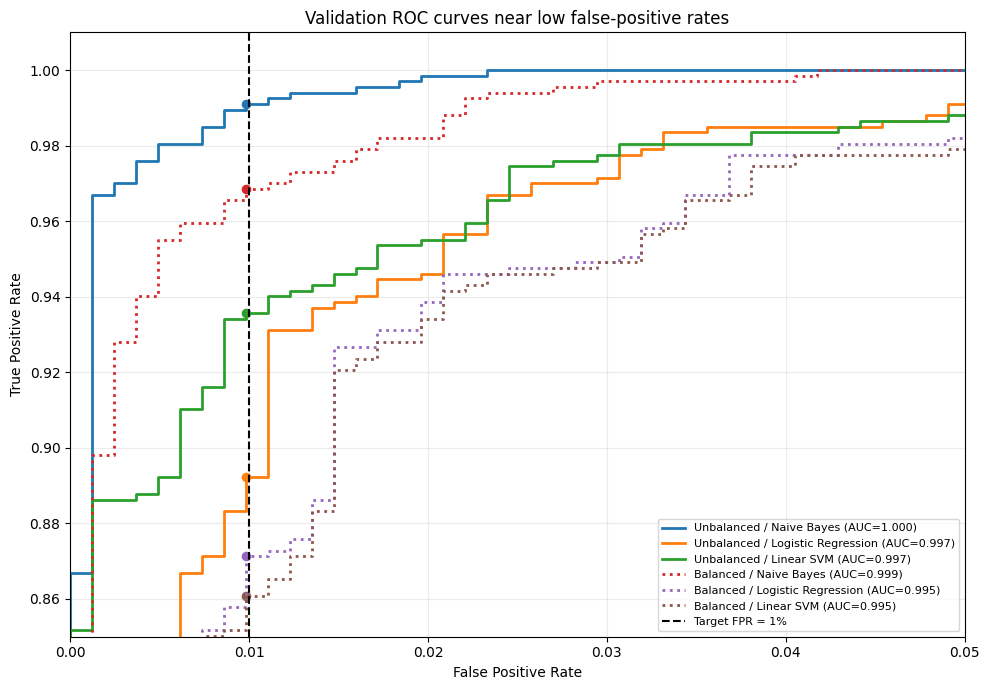

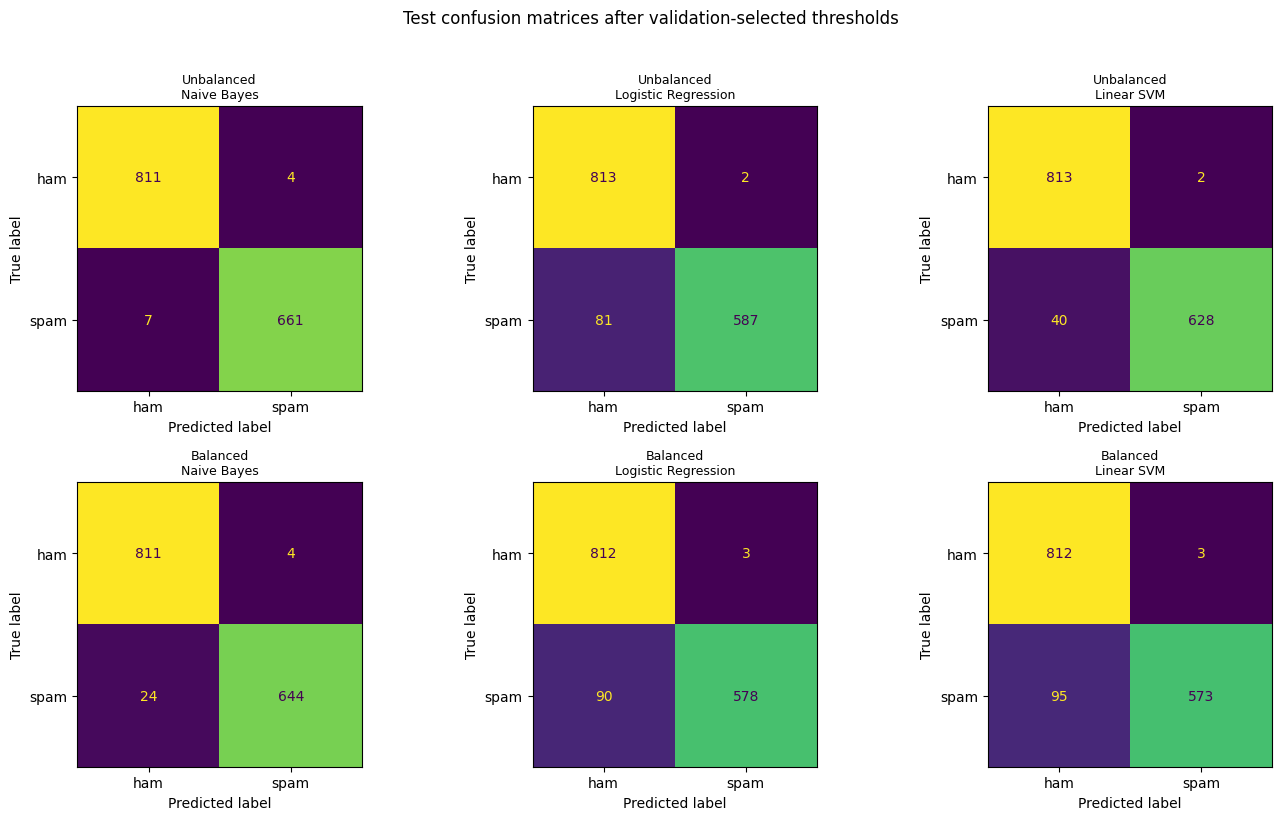

In [61]:
plt.figure(figsize=(10, 7))
line_styles = {"Balanced": ":", "Unbalanced": "-"}
for curve in val_roc_curves:
    plt.plot(
        curve["fpr"],
        curve["tpr"],
        linestyle=line_styles.get(curve["training_strategy"], "-"),
        linewidth=2,
        label=f'{curve["training_strategy"]} / {curve["model"]} (AUC={curve["auc"]:.3f})'
    )
    plt.scatter(curve["selected_validation_FPR"], curve["selected_validation_TPR"], s=35)
    
plt.axvline(target_fpr, color="black", linestyle="--", linewidth=1.5, label="Target FPR = 1%")
plt.xlim(0, 0.05)
plt.ylim(0.85, 1.01)
plt.title("Validation ROC curves near low false-positive rates")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.25)
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# Show Test Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for axis, payload in zip(axes, test_matrices):
    display_obj = ConfusionMatrixDisplay(confusion_matrix=payload["matrix"], display_labels=["ham", "spam"])
    display_obj.plot(ax=axis, values_format="d", colorbar=False)
    axis.set_title(f'{payload["training_strategy"]}\n{payload["model"]}', fontsize=9)
for axis in axes[len(test_matrices):]:
    axis.axis("off")
plt.suptitle("Test confusion matrices after validation-selected thresholds", y=1.02)
plt.tight_layout()
plt.show()


### STEP 10.2 — Data Failure Analysis For 99/1 Target


Selected Best Model: Unbalanced / Naive Bayes
Validation FPR: 0.0098, TPR: 0.9910
Test FPR: 0.0049, Recall/TPR: 0.9895
Selected Threshold: 0.3288


,source_profile,sources,rows,ham,spam
0,mixed,10,12960,8291,4669


label,source_family,ham,spam,total,spam_rate,source_profile
9,spamassassin,4091,668,4759,0.140366,mixed
2,aueb_enron3_spam_ham,493,494,987,0.500507,mixed
8,kaggle_email_spam_classification,437,547,984,0.555894,mixed
1,aueb_enron2_spam_ham,490,488,978,0.498978,mixed
0,aueb_enron1_spam_ham,491,456,947,0.481521,mixed
3,aueb_enron4_spam_ham,492,444,936,0.474359,mixed
7,huggingface_kimdongh_spam_dataset,471,446,917,0.486369,mixed
5,aueb_enron6_spam_ham,480,423,903,0.468439,mixed
6,huggingface_enron_spam,384,404,788,0.512690,mixed
4,aueb_enron5_spam_ham,462,299,761,0.392904,mixed


,source_family,rows,ham_rows,spam_rows,FP,FN,TP,TN,FPR,FNR,TPR
10,spamassassin,191,119,72,2,0,72,117,0.0168,0.0000,1.0000
1,aueb_enron2_spam_ham,148,84,64,1,0,64,83,0.0119,0.0000,1.0000
6,huggingface_enron_spam,122,60,62,1,0,62,59,0.0167,0.0000,1.0000
8,kaggle_email_spam_classification,137,56,81,0,3,78,56,0.0000,0.0370,0.9630
7,huggingface_kimdongh_spam_dataset,146,75,71,0,1,70,75,0.0000,0.0141,0.9859
5,aueb_enron6_spam_ham,130,62,68,0,1,67,62,0.0000,0.0147,0.9853
0,aueb_enron1_spam_ham,126,71,55,0,1,54,71,0.0000,0.0182,0.9818
4,aueb_enron5_spam_ham,107,59,48,0,1,47,59,0.0000,0.0208,0.9792
2,aueb_enron3_spam_ham,158,84,74,0,0,74,84,0.0000,0.0000,1.0000
3,aueb_enron4_spam_ham,141,68,73,0,0,73,68,0.0000,0.0000,1.0000


,label,rows,near_threshold_rows,near_threshold_rate,score_min,score_median,score_max
0,ham,815,4,0.0049,0.0000,0.0071,0.5231
1,spam,668,14,0.0210,0.2186,0.9383,0.9999


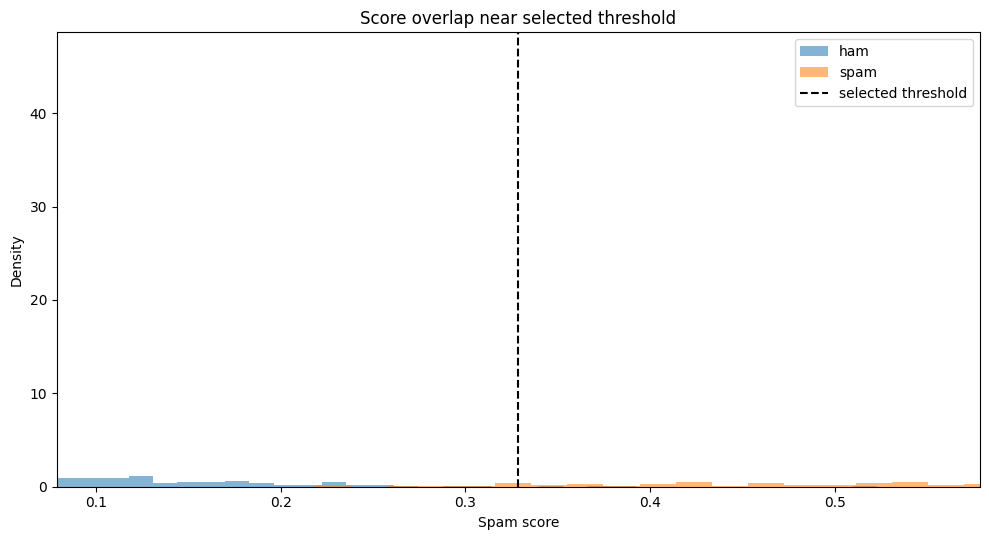

False positives closest to threshold


,error_type,label,prediction,score,threshold_distance,source_family,subject,snippet
1387,FP,ham,spam,0.3405,0.0117,aueb_enron2_spam_ham,ms 150,ms dear friends family april joining thousands...
775,FP,ham,spam,0.3715,0.0427,spamassassin,Re: My brain hurts,brain hurts wed jul robert harley wrote workin...
926,FP,ham,spam,0.3894,0.0606,spamassassin,Neat Net Tricks Standard Issue 131 - August 15...,neat net tricks standard issue august issue se...
1446,FP,ham,spam,0.5231,0.1943,huggingface_enron_spam,,amazon order greetings amazon thought like kno...


False negatives closest to threshold


,error_type,label,prediction,score,threshold_distance,source_family,subject,snippet
1465,FN,spam,ham,0.3258,0.0030,aueb_enron6_spam_ham,obtain a better job,obtain better job real verifiable egree univer...
64,FN,spam,ham,0.3226,0.0062,aueb_enron5_spam_ham,uk ' s leading pc specialist,uk leading pc specialist nationwide pc repairs...
169,FN,spam,ham,0.3165,0.0123,aueb_enron1_spam_ham,"so , it ' s me , varenukha",varenukha sorry taking long finally site askin...
1409,FN,spam,ham,0.2999,0.0289,kaggle_email_spam_classification,,fleming nov simulate clicking trigger user ope...
1405,FN,spam,ham,0.2901,0.0387,kaggle_email_spam_classification,,et ap news funding issue realclearpolitics tec...
894,FN,spam,ham,0.2742,0.0546,huggingface_kimdongh_spam_dataset,,minnesota clinch wild card playoff spot loss c...
927,FN,spam,ham,0.2186,0.1102,kaggle_email_spam_classification,,ermx goes wild wallst net does feature intervi...


,rows,labels,sources,text_preview


,error_type,token,count
0,FP,ms,20
1,FP,nnt,16
2,FP,time,11
3,FP,amazon,10
4,FP,address,8
5,FP,web,8
6,FP,frenchie,7
7,FP,information,7
8,FP,issue,7
9,FP,just,7


,issue,evidence,impact,next_action
0,Source-label confounding,0 ham-only source families with 0 rows; source...,Model can learn source/domain style instead of...,"Evaluate by source family, reduce source artif..."
1,Score overlap around threshold,Near threshold (+/-0.05): 4 ham and 14 spam rows.,Raising TPR pulls overlapping ham across thres...,Add stronger features such as URL/header/domai...
2,False positives / false negatives are source-p...,"Top source errors include spamassassin, aueb_e...",Some sources dominate residual errors; global ...,"Inspect source-specific samples, label noise, ..."
3,Exact conflicting clean_text labels,0 conflicting clean_text groups shown; total d...,"If conflicts exist, no threshold can classify ...",Deduplicate/resolve conflicting labels before ...
4,Token/artifact-driven errors,FP/FN top-token tables show the words most ass...,TF-IDF may be reacting to artifacts rather tha...,Extend cleaning and add robust non-text featur...


In [62]:
# Chọn mô hình tốt nhất có validation FPR <= 1% và TPR cao nhất
valid_candidates = df_tuning_results[df_tuning_results["validation_FPR"] <= target_fpr].sort_values(
    ["validation_TPR", "validation_FPR"],
    ascending=[False, True]
)
if valid_candidates.empty:
    best_candidate = df_tuning_results.sort_values(["validation_FPR", "validation_TPR"], ascending=[True, False]).iloc[0]
else:
    best_candidate = valid_candidates.iloc[0]
    
print(f"Selected Best Model: {best_candidate['training_strategy']} / {best_candidate['model']}")
print(f"Validation FPR: {best_candidate['validation_FPR']:.4f}, TPR: {best_candidate['validation_TPR']:.4f}")
print(f"Test FPR: {best_candidate['test_FPR']:.4f}, Recall/TPR: {best_candidate['recall']:.4f}")
print(f"Selected Threshold: {best_candidate['selected_threshold']:.4f}")

best_key = f"{best_candidate['training_strategy']}_{best_candidate['model']}"
best_payload = trained_models[best_key]
best_model = best_payload["model"]
best_vec = best_payload["vectorizer"]
best_thresh = best_payload["threshold"]
best_score_type = best_payload["score_type"]

# Phân tích lỗi trên tập Test sử dụng clean_plus_meta
x_test_mat_best = best_vec.transform(test_data["clean_plus_meta"])
if best_score_type == "decision_score":
    test_scores_best = best_model.decision_function(x_test_mat_best)
else:
    spam_col_best = list(best_model.classes_).index(positive_label)
    test_scores_best = best_model.predict_proba(x_test_mat_best)[:, spam_col_best]
    
analysis_errors = model_checker.error_analysis_frame(
    test_data,
    test_scores_best,
    threshold=best_thresh,
    positive_label=positive_label,
    text_column="clean_plus_meta"
)

source_confounding = model_checker.source_label_confounding(before_balance_data)
source_profile_summary = (
    source_confounding.groupby("source_profile")
    .agg(
        sources=("source_family", "count"),
        rows=("total", "sum"),
        ham=("ham", "sum"),
        spam=("spam", "sum"),
    )
    .reset_index()
    .sort_values("rows", ascending=False)
)
display(source_profile_summary)
display(source_confounding.sort_values("total", ascending=False).head(15))

source_errors = model_checker.source_error_summary(analysis_errors)
for column in ["FPR", "FNR", "TPR"]:
    source_errors[column] = source_errors[column].round(4)
display(source_errors.head(15))

overlap_summary = model_checker.score_overlap_summary(analysis_errors, threshold=best_thresh, window=0.05)
for column in ["near_threshold_rate", "score_min", "score_median", "score_max"]:
    overlap_summary[column] = overlap_summary[column].round(4)
display(overlap_summary)

utils._plot_score_overlap(analysis_errors, best_thresh, best_score_type)
fp_near, fn_near = utils._display_nearest_errors(analysis_errors)

# Kiểm tra trùng lặp trên tập train sử dụng clean_plus_meta
conflicts = model_checker.conflicting_clean_texts(
    train_data,
    text_column="clean_plus_meta",
    top_n=20,
)
display(conflicts)

fp_tokens = model_checker.top_error_tokens(analysis_errors, "FP", text_column="clean_plus_meta", top_n=20)
fn_tokens = model_checker.top_error_tokens(analysis_errors, "FN", text_column="clean_plus_meta", top_n=20)
error_tokens = pd.concat([fp_tokens, fn_tokens], ignore_index=True)
display(error_tokens)

issue_summary = utils._build_issue_summary(source_profile_summary, overlap_summary, source_errors, conflicts)
display(issue_summary)


## STEP 11 — Save Model & Deployment Check

Lưu trữ mô hình tối ưu (kèm vectorizer và ngưỡng quyết định) và chạy thử nghiệm nhận diện email mới.


In [63]:
import joblib

# Lưu payload chứa mô hình scratch, vectorizer và ngưỡng
saved_payload = {
    "model": best_model,
    "vectorizer": best_vec,
    "threshold": best_thresh,
    "score_type": best_score_type
}
joblib.dump(saved_payload, paths["model"])
print(f"Saved scratch model payload to {paths['model'].relative_to(PROJECT_ROOT)}")

# Thử nghiệm dự đoán email mới
emails = [
    "Win cash now! Click the prize link and claim your bonus today.",
    "Hi team, attached are the meeting notes and next steps from today's planning call."
]

loaded_payload = joblib.load(paths["model"])
loaded_model = loaded_payload["model"]
loaded_vec = loaded_payload["vectorizer"]
loaded_thresh = loaded_payload["threshold"]
loaded_score_type = loaded_payload["score_type"]

email_series = pd.Series(emails, name="email_text")
clean_new_emails = email_series.map(preprocess.clean_email_text)

# Định dạng email mới dưới dạng clean_plus_meta với metadata rỗng
new_emails_df = pd.DataFrame({
    "clean_text": clean_new_emails,
    "subject": ["", ""],
    "sender": ["", ""],
    "source_family": ["", ""],
    "source": ["", ""]
})
new_emails_df = utils.add_threshold_metadata_text(new_emails_df, "clean_text")
new_features = loaded_vec.transform(new_emails_df["clean_plus_meta"])

if loaded_score_type == "decision_score":
    new_scores = loaded_model.decision_function(new_features)
else:
    spam_col_idx = list(loaded_model.classes_).index(positive_label)
    new_scores = loaded_model.predict_proba(new_features)[:, spam_col_idx]
    
new_predictions = np.where(new_scores >= loaded_thresh, "spam", "ham")

table = pd.DataFrame({
    "email_text": email_series,
    "clean_text": clean_new_emails,
    "prediction": new_predictions,
    "score": new_scores.round(4)
})
display(table)

# In trạng thái báo cáo dự án
display(crawl.report_status(paths["metrics_dir"], PROJECT_ROOT))


Saved scratch model payload to models/spam_nb.joblib


,email_text,clean_text,prediction,score
0,Win cash now! Click the prize link and claim y...,win cash prize link claim bonus today,spam,0.8423
1,"Hi team, attached are the meeting notes and ne...",hi team attached meeting notes steps today's p...,ham,0.0547


,report,status
0,data/processed/metrics/preprocessing_balance_r...,exists
1,data/processed/metrics/classification_report.txt,exists
2,data/processed/metrics/model_summary.md,exists
3,data/processed/metrics/per_source_classificati...,exists
4,data/processed/metrics/cross_source_holdout_re...,exists
